In [1]:
%load_ext autoreload
%autoreload 2

# Accuracy test

In [3]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import itertools
import sys 
sys.path.append('/home/lhasbini/como_school/como_project4/src/')
from text_processing_functions import *
from constants import *
import LLM_functions
from plot_functions import *
from post_process_functions import *
from accuracy import *
from data import *
import copy as cp
import ast

#Package for accuracy 
from sklearn.metrics.pairwise import cosine_similarity

#For plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import cartopy.io.shapereader as shpreader
from cartopy.io import shapereader

In [7]:
reports_chat = pd.read_csv(DATA_OUT_LLMS+"labelled_reports_response_llm_levels_haz_types_subtypes_impacts.csv")
reports_labelled = pd.read_csv(DATA_LABELLED+"labelled_example_haz-subtype-emdat_chat-format_laura.csv")

In [8]:
reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(separate_locs))
reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(remove_startspace))
reports_chat['region'] = reports_chat.apply(lambda row: [item for item in (row['region'] or []) + (row['state'] or []) if item is not None], axis=1)
reports_chat = reports_chat.drop('state', axis=1)

In [9]:
reports_chat = clean_chat_format(reports_chat)

In [13]:
reports_chat.appealCode.nunique()

24

In [10]:
accuracy_columns = ["hazardType", "hazardSubtypes", "country", "region", "city", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay", "hazardName"]
accuracy = calculate_precision_per_report(reports_chat, reports_labelled, accuracy_columns)

In [11]:
accuracy

,hazardType,hazardSubtypes,country,region,city,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName
0,0.557022,0.373873,0.661084,2.125433,0.817973,0.941176,0.779412,0.735294,0.911765,1.058824,1.088235,1.019608


In [11]:
accuracy_per_hazard = calculate_precision_per_hazardType(reports_chat, reports_labelled, accuracy_columns)

In [12]:
df_list = []

for key, df in accuracy_per_hazard.items():
    # Add a new column 'HAZARD' with the key value
    df['HAZARD'] = key
    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

In [13]:
combined_df

,hazardType,hazardSubtypes,country,region,city,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,HAZARD
0,0.666667,0.666667,0.333333,1.083333,0.666667,1.0,0.50,0.000000,1.00,0.00,0.00,1.000000,Drought
1,1.000000,0.707107,1.000000,14.000000,0.040000,0.5,0.50,0.500000,1.00,1.00,1.00,1.000000,Wildfire
2,1.000000,1.000000,1.000000,0.428571,1.000000,1.0,0.50,0.333333,1.00,2.00,2.00,1.000000,Earthquake
3,0.555556,0.490468,0.508594,2.900000,3.622222,1.0,1.20,1.200000,1.00,1.20,1.20,1.000000,Mass movement
4,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Volcanic activity
5,0.769231,0.285162,0.755115,1.761667,0.865722,1.0,0.95,0.950000,0.95,0.95,0.95,1.000000,Flood
6,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wave action
7,0.500000,0.176777,0.500000,2.022727,4.562500,1.0,1.00,1.000000,1.00,1.00,1.00,1.000000,Extreme temperature
8,0.142857,0.142857,0.123718,0.400000,1.500000,1.0,1.00,1.000000,1.00,1.00,1.00,0.333333,Storm


In [14]:
accuracy_per_hazardSubtype = calculate_precision_per_hazardSubtypes(reports_chat, reports_labelled, accuracy_columns)
df_list = []

for key, df in accuracy_per_hazardSubtype.items():
    # Add a new column 'HAZARD' with the key value
    df['HAZARD'] = key
    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

In [15]:
combined_df

,hazardType,hazardSubtypes,country,region,city,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,HAZARD
0,0.666667,0.666667,0.333333,1.083333,0.666667,1.0,0.500000,0.0,1.0,0.0,0.0,1.0,drought
1,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wildfire
2,1.000000,1.000000,1.000000,14.000000,0.040000,0.5,0.500000,0.5,1.0,1.0,1.0,1.0,forest fire
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,land fire
4,1.000000,1.000000,1.000000,1.000000,4.000000,1.0,0.666667,0.4,1.0,2.0,2.0,1.0,ground movement
5,1.000000,1.000000,1.000000,0.750000,1.000000,1.0,1.000000,1.0,1.0,2.0,2.0,1.0,tsunami
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,avalanche
7,0.714286,0.714286,0.714286,2.300000,3.422222,1.0,1.200000,1.2,1.0,1.2,1.2,1.0,landslide
8,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rockfall
9,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sudden subsidence


In [17]:
subset_hazard = "Storm"
grouping_columns = ["hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 
report_labelled_grouping = reports_labelled.loc[reports_labelled.hazardType == "Storm"].copy()
report_labelled_grouping[grouping_columns] = report_labelled_grouping[grouping_columns].fillna('missing')
report_labelled_event = report_labelled_grouping.groupby(grouping_columns)

report_chat_grouping = reports_chat.loc[(reports_chat.hazardType == "Storm") & (reports_chat.appealCode.isin(reports_labelled.appealCode.unique()))].copy()
report_chat_grouping[grouping_columns] = report_chat_grouping[grouping_columns].fillna('missing')
report_chat_event = report_chat_grouping.groupby(grouping_columns)

In [20]:
for group in report_chat_event.groups : 
    print(group)

('Storm', 'missing', 'Brazil', 2021, 11.0, 1.0, 2022, 5.0, 31.0)
('Storm', 'storm surge', 'Kiribati', 2015, 3.0, 9.0, 2015, 3.0, 9.0)
('Storm', 'storm surge', 'Solomon Islands', 2015, 3.0, 9.0, 2015, 3.0, 9.0)
('Storm', 'tropical storm', 'Algeria', 2024, 9.0, 5.0, 2024, 9.0, 8.0)
('Storm', 'tropical storm', 'Kiribati', 2015, 3.0, 9.0, 2015, 3.0, 9.0)
('Storm', 'tropical storm', 'Mozambique', 2024, 3.0, 'missing', 2024, 3.0, 'missing')
('Storm', 'tropical storm', 'Papua New Guinea', 2015, 3.0, 9.0, 2015, 3.0, 9.0)
('Storm', 'tropical storm', 'Solomon Islands', 2015, 3.0, 9.0, 2015, 3.0, 9.0)


In [21]:
for group in report_labelled_event.groups : 
    print(group)

('Storm', 'hail', 'Uganda', 2024.0, 4.0, '', '', '', '')
('Storm', 'storm surge', 'Kiribati', '', '', '', '', '', '')
('Storm', 'storm surge', 'Solomon Islands', '', '', '', '', '', '')
('Storm', 'storm surge', 'Tuvalu', '', '', '', '', '', '')
('Storm', 'tropical storm', 'Kiribati', '', '', '', '', '', '')
('Storm', 'tropical storm', 'Papua New Guinea', '', '', '', '', '', '')
('Storm', 'tropical storm', 'Solomon Islands', '', '', '', '', '', '')


In [21]:
reports_chat.loc[reports_chat.country == 'Brazil']

,Unnamed: 0,hazardType,country,region,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,hazardSubtypes,appealCode,location,reportDate,disasterType,country_iso3
156,17,Mass movement,Brazil,southeastern Brazil,None,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
157,17,Mass movement,Brazil,Bahia,None,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
158,17,Mass movement,Brazil,Minas Gerais,None,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
159,17,Mass movement,Brazil,None,Jucuruçu,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
160,17,Mass movement,Brazil,None,Medeiros Neto,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
161,17,Mass movement,Brazil,None,Itamaraju,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
162,17,Mass movement,Brazil,None,Petrópolis,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
163,17,Mass movement,Brazil,None,Angra dos Reis,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
164,17,Mass movement,Brazil,None,Paraty,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,landslide,MDRBR010,Brazil,2024-05-24,Flood,BRA
165,17,Mass movement,Brazil,southeastern Brazil,None,"Heavy rainfall, including the passage of a sub...",2021,11.0,1.0,2022,5.0,31.0,NaN,rockfall,MDRBR010,Brazil,2024-05-24,Flood,BRA


In [20]:
reports_chat.loc[reports_chat.country == 'Algeria']

,Unnamed: 0,hazardType,country,region,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,hazardSubtypes,appealCode,location,reportDate,disasterType,country_iso3
0,0,Flood,Algeria,Béchar,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
1,0,Flood,Algeria,Tamanrasset,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
2,0,Flood,Algeria,El Bayadh,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
3,0,Flood,Algeria,Tiaret,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
4,0,Flood,Algeria,Tindouf,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
5,0,Flood,Algeria,Naama,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
6,0,Flood,Algeria,None,Béchar,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
7,0,Flood,Algeria,None,Elbayadh,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
8,0,Flood,Algeria,None,Beni Abbes,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
9,0,Flood,Algeria,None,Tamanrasset,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA


In [18]:
reports_chat.loc[reports_chat.country == 'Algeria']

,Unnamed: 0,hazardType,country,region,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,hazardSubtypes,appealCode,location,reportDate,disasterType,country_iso3
0,0,Flood,Algeria,Béchar,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
1,0,Flood,Algeria,Tamanrasset,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
2,0,Flood,Algeria,El Bayadh,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
3,0,Flood,Algeria,Tiaret,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
4,0,Flood,Algeria,Tindouf,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
5,0,Flood,Algeria,Naama,None,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
6,0,Flood,Algeria,None,Béchar,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
7,0,Flood,Algeria,None,Elbayadh,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
8,0,Flood,Algeria,None,Beni Abbes,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA
9,0,Flood,Algeria,None,Tamanrasset,"The most affected areas include Béchar, Elbaya...",2024,9.0,5.0,2024,9.0,8.0,NaN,None,MDRDZ011,Algeria,2024-09-22,Famine / Food Insecurity,DZA


In [91]:
appealCodeTest = "MDR55001"
reports_labelled_rep = reports_labelled.loc[reports_labelled.appealCode == appealCodeTest]

In [92]:
reports_labelled_event = reports_labelled_rep.groupby(
    ["hazardType", "hazardSubtypes", "country", 
     "startYear", "startMonth", "startDay", 
     "endYear", "endMonth", "endDay"]
)

In [93]:
reports_labelled_event

In [94]:
grouping_columns = ["hazardType", "hazardSubtypes", "country", 
                    "startYear", "startMonth", "startDay", 
                    "endYear", "endMonth", "endDay"]

# Apply fillna('missing') to only the grouping columns
reports_labelled_rep[grouping_columns] = reports_labelled_rep[grouping_columns].fillna('missing')
reports_labelled_event = reports_labelled_rep_filled.groupby(
    ["hazardType", "hazardSubtypes", "country", 
     "startYear", "startMonth", "startDay", 
     "endYear", "endMonth", "endDay"]
)

keys = reports_labelled_event.groups.keys()
 
for i in keys:
    event = reports_labelled_event.get_group(i)
    print(reports_labelled_event.get_group(i))
    print(event['region'])
    print('\n')

  hazardType hazardSubtypes   country  region     city  \
9      Flood  coastal flood  Kiribati  Tarawa  missing   

                                  locationAnnotation startYear startMonth  \
9  In Kiribati, rough seas, combined with tidal m...   missing    missing   

  startDay  endYear endMonth   endDay hazardName appealCode Country  \
9  missing  missing  missing  missing    missing   MDR55001     KIR   

   reportDate  
9  15/05/2015  
9    Tarawa
Name: region, dtype: object


   hazardType hazardSubtypes           country   region          city  \
12      Flood        missing  Papua New Guinea  missing  Port Moresby   

                                   locationAnnotation startYear startMonth  \
12  The National Capital District, the location of...   missing    missing   

   startDay  endYear endMonth   endDay hazardName appealCode Country  \
12  missing  missing  missing  missing    missing   MDR55001     PNG   

    reportDate  
12  15/05/2015  
12    missing
Name: region, 

/tmp/ipykernel_410952/798937012.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reports_labelled_rep[grouping_columns] = reports_labelled_rep[grouping_columns].fillna('missing')


In [96]:
reports_labelled_rep['region']

0                Tamana
1                Tamana
2                Arorae
3                Onotoa
4               Nonouti
5                Tamana
6                Arorae
7                Onotoa
8               Nonouti
9                Tarawa
10                  NaN
11                  NaN
12                  NaN
13                  NaN
14               Temotu
15              Malaita
16               Temotu
17              Malaita
18             Funafuti
19              Nanumea
20             Nanumaga
21               Niutao
22                  Nui
23              Vaitupu
24            Nukufetau
25    Nukulaelae atolls
Name: region, dtype: object

In [59]:
grouping_columns = ["hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 

In [60]:
grouping_columns.index("hazardType")

0

In [58]:
for dict_ in reports_labelled_event.groups.keys() : 
    print(dict_)
    print(dict_[0])

('Flood', 'coastal flood', 'Kiribati', nan, nan, nan, nan, nan, nan)
Flood
('Flood', nan, 'Papua New Guinea', nan, nan, nan, nan, nan, nan)
Flood
('Mass Movement', 'landslide', 'Papua New Guinea', nan, nan, nan, nan, nan, nan)
Mass Movement
('Storm', 'storm surge', 'Kiribati', nan, nan, nan, nan, nan, nan)
Storm
('Storm', 'storm surge', 'Solomon Islands', nan, nan, nan, nan, nan, nan)
Storm
('Storm', 'storm surge', 'Tuvalu', nan, nan, nan, nan, nan, nan)
Storm
('Storm', 'tropical storm', 'Kiribati', nan, nan, nan, nan, nan, nan)
Storm
('Storm', 'tropical storm', 'Papua New Guinea', nan, nan, nan, nan, nan, nan)
Storm
('Storm', 'tropical storm', 'Solomon Islands', nan, nan, nan, nan, nan, nan)
Storm


In [4]:
path_test_csv = '/scratchx/lhasbini/como_school/'

######   Predicted with hazard detected by regex
#labelled_chat_output = pd.read_csv(path_test_csv+'11_label_v2_predict_llmgpt-4o-mini.csv')
#labelled_chat_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_1.csv')
labelled_regex_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_subtypes_1.csv')
# labelled_chat_output = labelled_chat_output.loc[:,['Hazard', 'Country', 'Location', 'Start_Date', 'End_Date', 'appealCode']]
# labelled_chat_output = labelled_chat_output.dropna(subset=['Hazard']).copy()

# #Convert country code 
# labelled_chat_output['Country'] = labelled_chat_output['Country'].str.extract(r"\['(.*?)'\]")
# labelled_chat_output['Country'] = [country_name_to_iso3(cntr) for cntr in labelled_chat_output['Country']]

###### Predicted with hazard detected by CHAT
labelled_chat_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_haz_types_subtypes_1.csv')

#####    Labelled
labelled_example = pd.read_csv(path_test_csv+'labelled_example_haz-subtype-emdat.csv')
labelled_example = labelled_example.rename(columns={'Locations': 'Location'})

In [5]:
#Add the em-dat main type 
# labelled_chat_output['Hazard_main'] = labbelled_chat_output['Hazard'].map(hazard_category_map)
labelled_example = labelled_example.rename(columns={"Hazard" : "Hazard_subtype"})
labelled_example['Hazard'] = labelled_example['Hazard_subtype'].map(hazard_category_map)

# Accuracy

In [6]:
unique_countries_ISO = [country.alpha_3 for country in pycountry.countries]
unique_dict = {
    'Hazard' : list(hazard_subtype_emdat), 
    'Hazard_subtype' : list(hazard_all_subtype_emdat), 
    'Country' : unique_countries_ISO
}

In [7]:
## PROCESS THE FILES TO COMPUTE ACCURACY 
labelled_regex_output_acc                   = labelled_regex_output[["hazardType", "country_iso3", "appealCode", "hazardSubtypes"]]
labelled_regex_output_acc                   = labelled_regex_output_acc.rename(columns={'hazardType': 'Hazard', "country_iso3" : "Country", "hazardSubtypes" : "Hazard_subtype"})
labelled_regex_output_acc['Hazard_subtype'] = labelled_regex_output_acc['Hazard_subtype'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

labelled_chat_output_acc                   = labelled_chat_output[["hazardType", "country_iso3", "appealCode", "hazardSubtypes"]]
labelled_chat_output_acc                   = labelled_chat_output_acc.rename(columns={'hazardType': 'Hazard', "country_iso3" : "Country", "hazardSubtypes" : "Hazard_subtype"})
labelled_chat_output_acc['Hazard_subtype'] = labelled_chat_output_acc['Hazard_subtype'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [9]:
columns_accuracy = ['Hazard', "Hazard_subtype", 'Country']#['Hazard_Type', 'Hazard_Count', 'Country']
precision_regex = LLM_functions.calculate_precision_v2(labelled_regex_output_acc, labelled_example, columns_accuracy, unique_dict = unique_dict)
precision_chat = LLM_functions.calculate_precision_v2(labelled_chat_output_acc, labelled_example, columns_accuracy, unique_dict = unique_dict)

In [20]:
labelled_chat_output_acc.appealCode.unique()

array(['MDRDZ011', 'MDRPK026', 'MDRCM039', 'MDRBJ019', 'MDRSD034',
       'MDRNG041', 'MDRRW022', 'MDRZM022', 'MDRUG050', 'MDRMZ024'],
      dtype=object)

In [19]:
labelled_regex_output_acc.appealCode.unique()

array(['MDRPK026', 'MDRSD034', 'MDRRW022', 'MDRZM022', 'MDRUG050',
       'MDRMZ024'], dtype=object)

In [23]:
appealmissed = ["MDRDZ011", "MDRCM039", "MDRBJ019", "MDRNG041"]
labelled_chat_output_acc.loc[labelled_chat_output_acc.appealCode.isin(appealmissed)]

,Hazard,Country,appealCode,Hazard_subtype
0,Flood,DZA,MDRDZ011,[]
1,Storm,DZA,MDRDZ011,[tropical storm]
14,Flood,CMR,MDRCM039,[riverine flood]
15,Flood,BEN,MDRBJ019,[riverine flood]
26,Flood,NGA,MDRNG041,[]
27,Flood,NGA,MDRNG041,[riverine flood]
28,Flood,NGA,MDRNG041,[]


In [12]:
precision_regex

,Hazard,Hazard_subtype,Country
0,0.683492,0.726265,1.0


In [11]:
precision_chat

,Hazard,Hazard_subtype,Country
0,0.825431,0.568005,1.0


# Plots 

In [123]:
df_output = df_cleaned.copy()

# Look for reports with MultiHazards 

# Count hazards per appealCode
hazard_counts = df_output['appealCode'].value_counts().reset_index()
hazard_counts.columns = ['appealCode', 'Hazard_Count']

# Add a new column to indicate if there are multiple hazards
df_output = df_output.merge(hazard_counts, on='appealCode')
df_output['Multi_Hazards'] = df_output['Hazard_Count'] > 1

# Drop the Hazard_Count column if no longer needed
df_output.drop(columns=['Hazard_Count'], inplace=True)

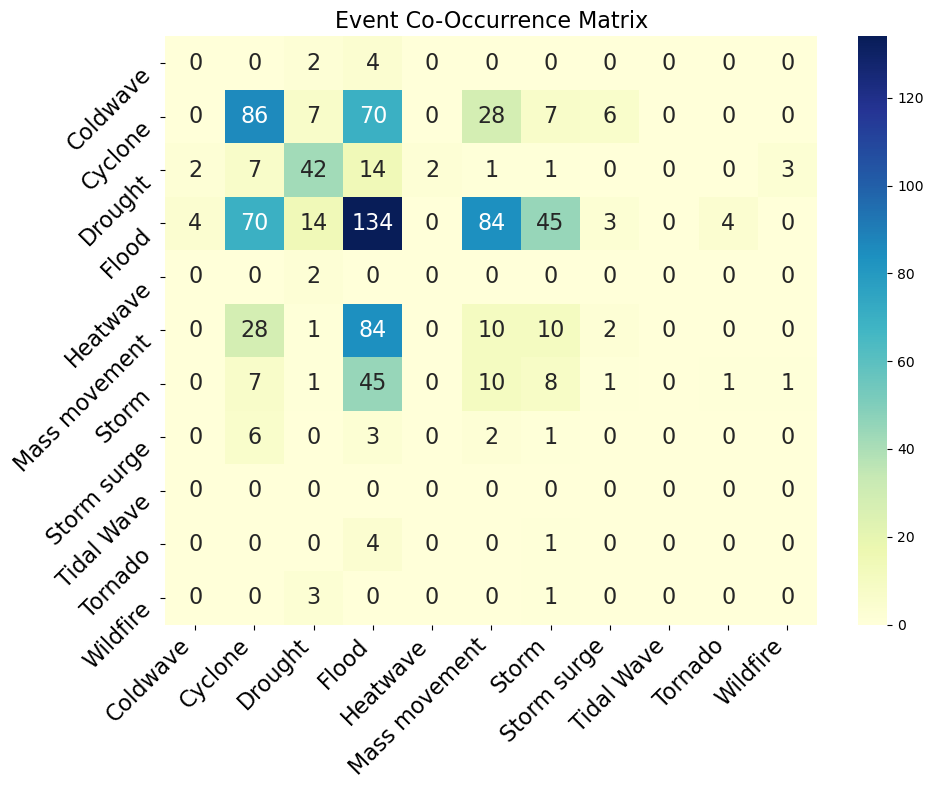

In [129]:
fig = matrix_co_occurence(df_output, sorted(unique_hazards))

In [133]:
#Map number of compound in each countries
unique_countries_haz = np.unique(df_output['Country']).tolist()
nb_compound_country = {country: 0 for country in unique_countries_haz}

#dict(unique_countries_haz)
for appeal in df_output.appealCode.unique() : 
    report = df_output.loc[df_output.appealCode == appeal]
    #Check if more than one hazard are identified
    if len(report)>1 : 
        unique_countires_rep = np.unique(report['Country'].tolist())
        for country in unique_countires_rep : 
            nb_compound_country[country]+=1

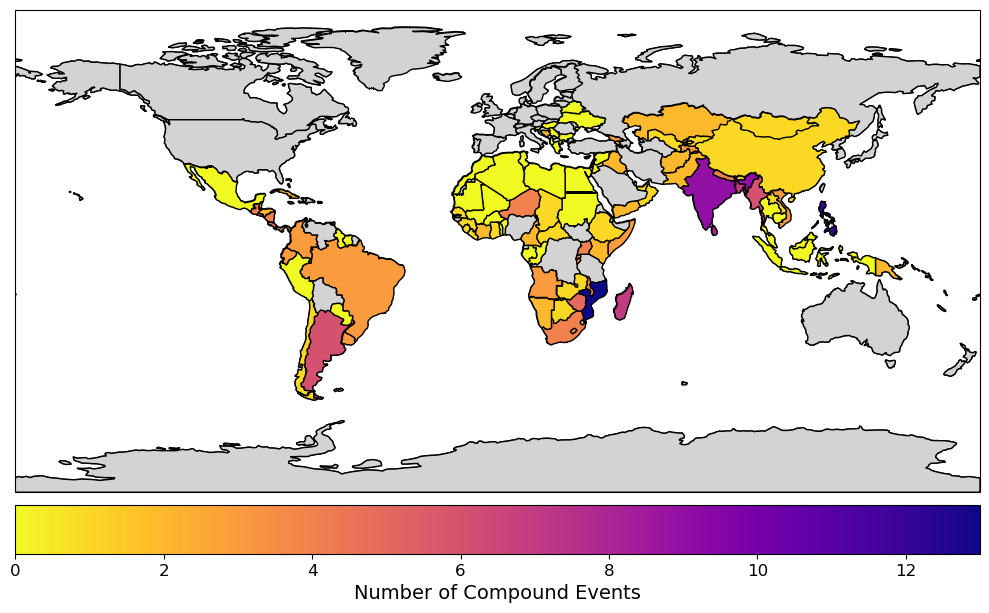

In [157]:
map_nb_compound = map_nb_compounds(nb_compound_country,  
                                   colormap = 'plasma_r', vmax = max(nb_compound_country.values()), cbar_title='Number of Compound Events',
                                   save=False)

In [158]:
hazard_counts = df_output.groupby(['Country', 'Hazard']).size().unstack(fill_value=0)

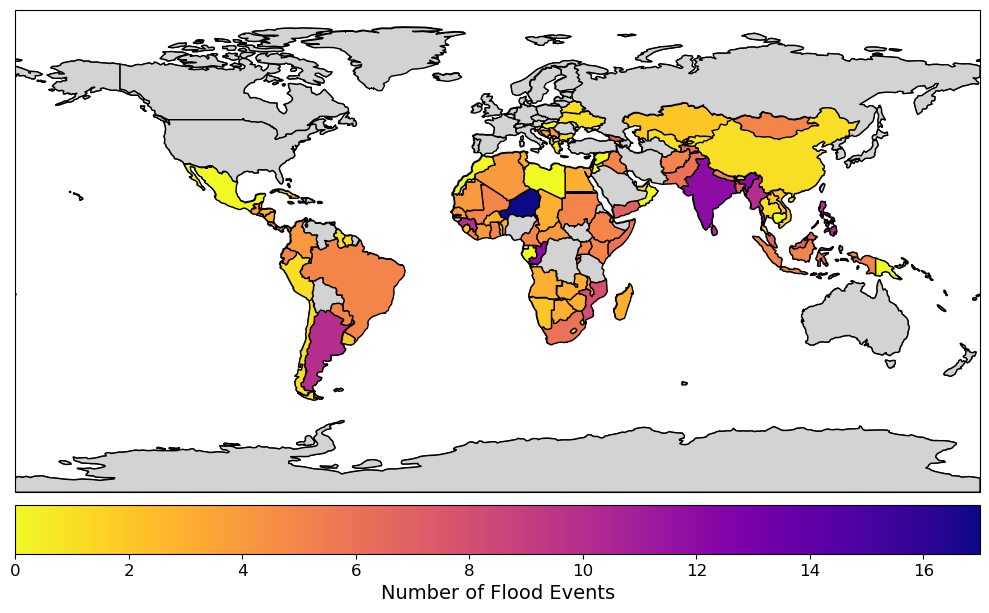

In [164]:
hazard_test = 'Flood'
map_nb_compound = map_nb_compounds(hazard_counts[hazard_test],  
                                   colormap = 'plasma_r', vmax = max(hazard_counts[hazard_test]), cbar_title='Number of Flood Events',
                                   save=False)

In [165]:
#Total number of compounded hazard in each country 
df_mh = df_output.loc[df_output.Multi_Hazards == True]
hazard_counts_mh = df_mh.groupby(['Country', 'Hazard']).size().unstack(fill_value=0)

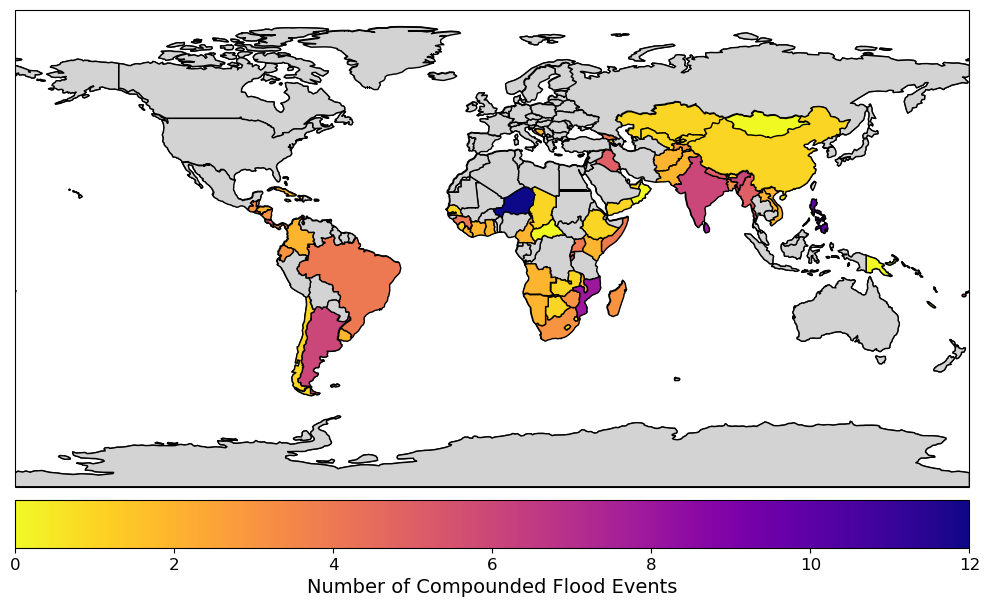

In [166]:
hazard_test = 'Flood'
map_nb_compound = map_nb_compounds(hazard_counts_mh[hazard_test],  
                                   colormap = 'plasma_r', vmax = max(hazard_counts_mh[hazard_test]), cbar_title='Number of Compounded Flood Events',
                                   save=False)

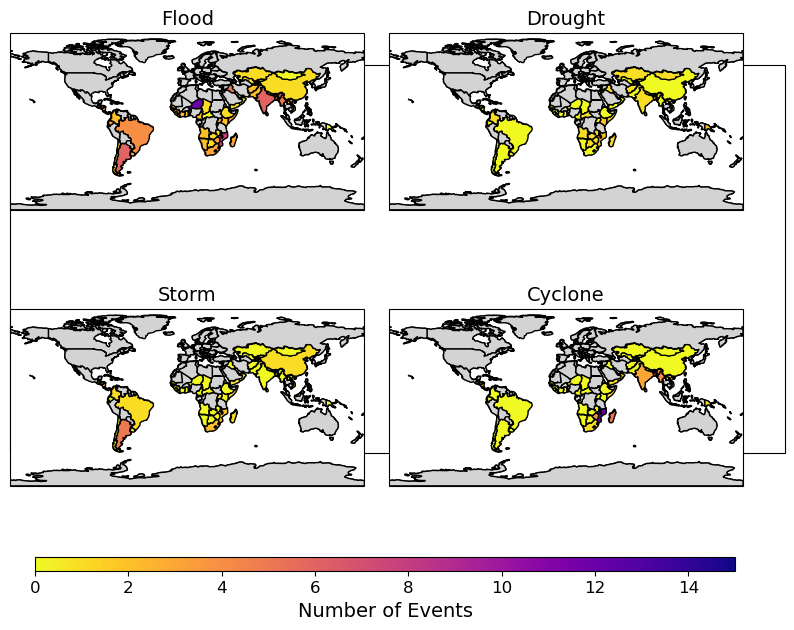

In [214]:
haz_plot = ['Flood', 'Drought', 'Storm', 'Cyclone']
map_multi_hazards = map_nb_hazards(hazard_counts_mh, haz_plot, vmax=15, cbar_title='Number of Events')

In [198]:
#Map number of compound in each countries
unique_countries_haz = np.unique(df_mh['Country']).tolist()
nb_compound_country = {country: 0 for country in unique_countries_haz}

#dict(unique_countries_haz)
for appeal in np.unique(df_mh.appealCode) : 
    report = df_mh.loc[df_mh.appealCode == appeal]
    #Check if more than one hazard are identified
    unique_countires_rep = np.unique(report['Country'].tolist())
    for country in unique_countires_rep : 
        nb_compound_country[country]+=1